# CYNAR paper 1 -- example 1: linear vortex (Brownian vortex)

The Brownian vortex of Di Terlizzi, Baiesi & Ritort (*New J. Phys.* **26**, 063013 (2024), Sec. 5,
`papers/P___2406NJP_DiTerlizziBaiesiRitort_VSR-models.pdf`, their Eq. 43): a particle in an anisotropic
harmonic trap $U(x,y)=\kappa(\alpha x^2+y^2)/2$, additionally driven by a nonconservative force
$\Phi(-y,\alpha x)$ everywhere perpendicular to $-\nabla U$. This gives $\dot{\boldsymbol x}=A\boldsymbol x+\sqrt{2D}\boldsymbol\xi$
with $A=\begin{pmatrix}-\alpha\kappa & -\Phi\\ \alpha\Phi & -\kappa\end{pmatrix}$ and isotropic
$D=T\mathsf I$; we fix $\kappa=T=1$ throughout, so $\alpha$ and $\Phi$ are the only free parameters, and
the closed form $\sigma=(1+\alpha)\Phi^2$, $\mathcal{T}=(1+\alpha)(\Phi^2-1)/4$, $\mathcal{G}=1+\alpha$
(matching `theory_linear_2N`) gives an exact sanity check for the whole pipeline. Detailed balance holds
if and only if $\Phi=0$, for any $\alpha$: the stationary density
$p_{\rm ss}(x,y)\propto\exp[-\kappa(\alpha x^2+y^2)/2T]$ never depends on $\Phi$ at all.

We fix $\alpha=0.2$ throughout and use three demonstrations, matching Sec. IV A of the paper:

- **Figure 1** and **Figure 2** (composed below, one each): the same five-panel comparison -- reconstructed
  $\nu$/$s$ fields, traffic vs. $H$, inflow rate vs. $\Delta x$, and $\sigma$ vs. $\Delta x$ -- run once at
  the equilibrium point $\Phi=0$ (Figure 1) and once at a representative nonequilibrium point $\Phi=2$
  (Figure 2): **merit (ii)** (cell-size stability), shown at both points with the identical pipeline.
- **Figure 3**: a fine sweep of $\Phi$ through $0$ at fixed cell size: **merit (i)** (unbiasedness).
  CYNAR's estimate should scatter around zero (including negative values) right at $\Phi=0$, while the
  $v^2$-method stays positive.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.linear import simulate_linear_diffusion, theory_linear_2N
from cynar.plot import plot_trajectory, plot_field_rho
from cynar import cfg, inflow

import common as C

np.set_printoptions(precision=4, suppress=True)

## Shared pipeline

Figures 1 and 2 run the identical sequence -- simulate, pick a stable traffic fit window via an
$H$-sweep, sweep the inflow-rate grid's cell size, and reconstruct the $\nu$/$s$ fields at a fixed cell
size -- so it is written once here and called at each $\Phi$ below, rather than duplicated. `Ne=1` is
used throughout: checked empirically (a diagnostic run, not kept in this notebook) that `Ne=2` is *less*
accurate than `Ne=1` at both $\Phi=0$ and $\Phi=2$ for this system and can even push
$\sigma_{\rm CYNAR}$ above $\sigma_{v^2}$, consistent with `common.sweep_traffic_vs_H`'s own docstring
warning that a richer model is prone to multimodal fits here.

In [2]:
dt = 2e-3
alph = 0.2  # fixed throughout this notebook


def run_pipeline(Phi, *, T=500_000, seed=12345, H_list=None, side0=(0.5, 0.3),
                  R_list=(1.0, 1.5, 2.0, 2.5, 3.0), side_recon_R=2.0):
    """Simulate the Brownian vortex at (alph, Phi) and run the full merit-B pipeline:
    traffic-vs-H sweep, cell-size sweep, and reconstructed nu/s fields at a fixed cell size."""
    if H_list is None:
        H_list = np.linspace(0.05, 0.5, 10)
    side0 = np.asarray(side0, dtype=float)
    R_list = np.asarray(R_list, dtype=float)

    A = np.array([[-alph, -Phi], [alph * Phi, -1.0]])
    D = np.array([[1.0, 0.0], [0.0, 1.0]])
    X = simulate_linear_diffusion(T, A, D, dt, oversampling=10, method="euler", seed=seed)
    Tr_true, sigma_true, G_true = theory_linear_2N(A, D)
    true_values = dict(Tr_true=Tr_true, G_true=G_true, sigma_true=sigma_true)

    traffic_result = C.sweep_traffic_vs_H(X, dt, H_list, N_slice=5, Ne=1)
    tr_star = C.pick_stable_Tr(traffic_result)

    cellsize_result = C.sweep_cellsize(X, dt, traffic_result["D_from_traffic"], side0, R_list, traffic_result["slices"])

    side_recon = side_recon_R * side0
    D_recon = traffic_result["D_from_traffic"][0]
    icfg = cfg.InflowCfg(n_min=2, thr_g=200.0)
    out_recon = inflow.grid_inflow(X, dt, side_recon, D_recon, cfg=icfg)

    return dict(
        Phi=Phi, X=X, A=A, D=D, true_values=true_values,
        traffic_result=traffic_result, tr_star=tr_star, cellsize_result=cellsize_result,
        side0=side0, side_recon=side_recon,
        edges=out_recon["grid"]["edges"], rho=out_recon["grid"]["rho"],
        nu=out_recon["grid"]["nu"], s=out_recon["grid"]["g"],
    )

## Run both points

In [3]:
pipe_eq = run_pipeline(Phi=0.0)
tv = pipe_eq["true_values"]; ts = pipe_eq["tr_star"]
print(f"Phi=0 (equilibrium):     Tr_true={tv['Tr_true']:.4f}  G_true={tv['G_true']:.4f}  sigma_true={tv['sigma_true']:.4f}"
      f"  |  H*={ts['H_star']:.2f}  Tr*={ts['Tr_star_mean']:.4f}+/-{ts['Tr_star_std']:.4f}")

pipe_neq = run_pipeline(Phi=2.0)
tv = pipe_neq["true_values"]; ts = pipe_neq["tr_star"]
print(f"Phi=2 (nonequilibrium):  Tr_true={tv['Tr_true']:.4f}  G_true={tv['G_true']:.4f}  sigma_true={tv['sigma_true']:.4f}"
      f"  |  H*={ts['H_star']:.2f}  Tr*={ts['Tr_star_mean']:.4f}+/-{ts['Tr_star_std']:.4f}")

C.save_result("linear_vortex_pipeline_eq", pipe_eq)
C.save_result("linear_vortex_pipeline_neq", pipe_neq)

Phi=0 (equilibrium):     Tr_true=-0.3000  G_true=1.2000  sigma_true=0.0000  |  H*=0.50  Tr*=-0.2565+/-0.0662
Phi=2 (nonequilibrium):  Tr_true=0.9000  G_true=1.2000  sigma_true=4.8000  |  H*=0.10  Tr*=0.9618+/-0.3158


### Example trajectory ($\Phi=2$, nonequilibrium)

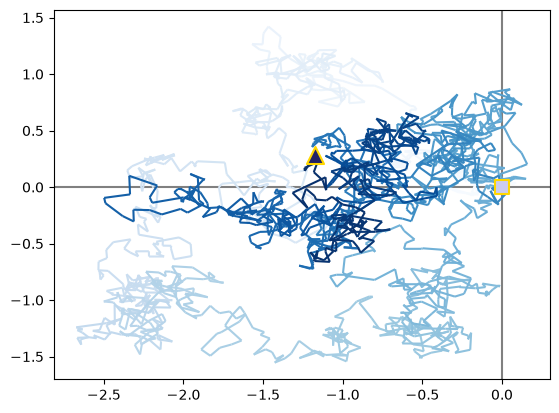

In [4]:
plot_trajectory(pipe_neq["X"], i=0, j=1, tmin=0, tmax=2000)

## Figures 1 and 2: single-column panel groups, one per $\Phi$ point

Each of the two figures below (equilibrium $\Phi=0$, then nonequilibrium $\Phi=2$) uses the same
five-panel layout, lettered fresh (a)-(e) within each figure for easier citation: row 1 is the
reconstructed $\rho$/$\nu$ (a) and $\rho$/$s$ (b) fields side by side, row 2 is traffic vs. $H$ (c) and
inflow rate vs. $\Delta x$ (d) side by side, and row 3 is $\sigma$ vs. $\Delta x$ (e), full width.

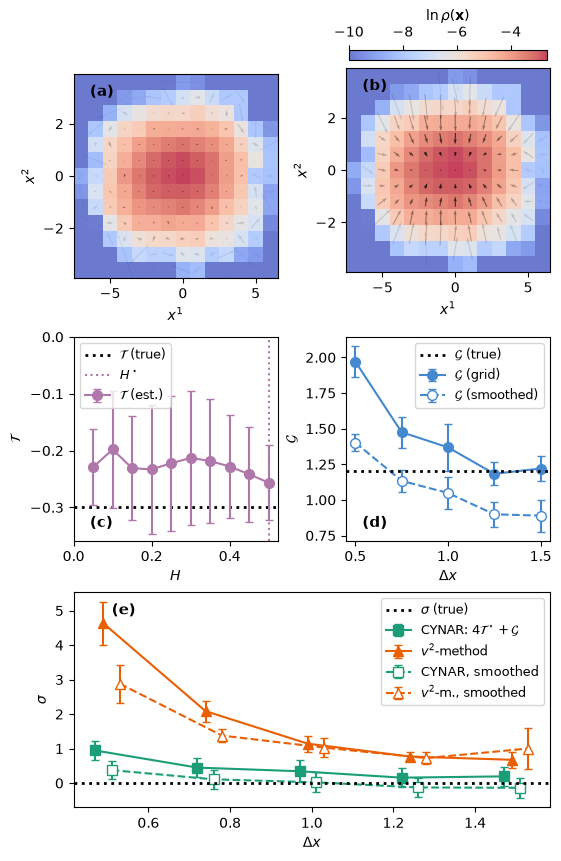

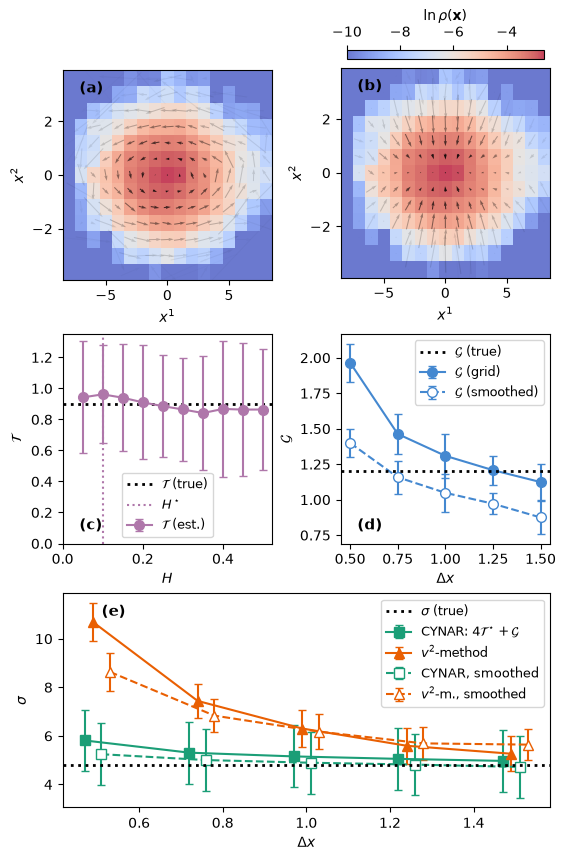

In [12]:
def build_panel_figure(pipe, save_name):
    fig, axd = plt.subplot_mosaic([["a", "b"], ["c", "d"], ["e", "e"]],
                                   figsize=(5.5, 8.5), constrained_layout=True)
    # panel (a) has no colorbar so that removing it doesn't unbalance (a) vs (b);
    # (a)-(d) all get a square box aspect for visual consistency, and panel (b)'s
    # colorbar is left free to stick out to the right rather than shrink its axes.
    plot_field_rho(pipe["edges"], pipe["rho"], pipe["nu"], ax=axd["a"], log=True, stride=1,
                    quiver_scale=4, quiver_width=0.005, obs=r"$\nu$", show_title=False,
                    panel_label="(a)", colorbar=False)
    plot_field_rho(pipe["edges"], pipe["rho"], pipe["s"], ax=axd["b"], log=True, stride=1,
                    quiver_scale=3, quiver_width=0.005, obs=r"$s$", show_title=False, panel_label="(b)")
    # (c)/(d) use lower-right panel labels: each panel's own legend spans
    # nearly the full width at the top, so no corner up there is free.
    C.plot_traffic_vs_H_panel(axd["c"], pipe["traffic_result"], pipe["tr_star"], pipe["true_values"],
                               panel_label="(c)", panel_label_kw=dict(loc="lower left"))
    axd["c"].set_xlim(0,)
    Tr0=pipe['true_values']['Tr_true']
    if Tr0>0: axd["c"].set_ylim(0,)
    if Tr0<0: axd["c"].set_ylim(None,0)
    C.plot_inflow_vs_cellsize_panel(axd["d"], pipe["cellsize_result"], pipe["true_values"],
                                     panel_label="(d)", panel_label_kw=dict(loc="lower left"))
    for k in ("a", "b", "c", "d"):
        axd[k].set_box_aspect(1)
    C.plot_sigma_vs_cellsize_panel(axd["e"], pipe["tr_star"], pipe["cellsize_result"], pipe["true_values"],
                                    panel_label="(e)")
    fig.savefig(str(C.FIGURES_DIR / save_name), dpi=300, bbox_inches="tight")
    return fig, axd


build_panel_figure(pipe_eq, "linear_vortex_eq.pdf")
plt.show()

build_panel_figure(pipe_neq, "linear_vortex_neq.pdf")
plt.show()

np.float64(-0.3)

## Figure 3: fine sweep through equilibrium

A finer $\Phi$-sweep at fixed $\alpha=0.2$ through the exact equilibrium point $\Phi=0$, at a single
fixed cell size (no per-point re-optimization of $\Delta x$): since $p_{\rm ss}$ is exactly
$\Phi$-independent, a single cell size is appropriate for the whole sweep by construction. We reuse the
same fixed cell size as the reconstructed-field panels above, `pipe_eq["side_recon"]`
($\Delta x=(1.0,0.6)$, i.e. $R=2$), rather than deriving a separate one from the (also
$\Phi$-independent) analytic stationary standard deviation -- both describe the same fixed-$\rho$
rationale, so there is no reason for them to differ. We use the smoothed inflow rate/local mean velocity
for both methods, not raw: at this cell size the raw inflow rate carries a small but persistent positive
bias near $\Phi=0$ (checked: it survives more statistics, so it is a genuine cell-size effect, not
finite-sample noise); smoothing substantially reduces it, though $\sigma_{\rm CYNAR}$ at $\Phi=0$
specifically still comes out small and positive rather than crossing to negative here (compare Fig. 1(e),
a different, coarser $\Delta x$-sweep, where the smoothed estimate does dip below zero at larger $\Delta
x$ -- both are genuine features of the respective sweeps, not in conflict).

In [6]:
Phi_list = np.arange(-8, 9) * 0.1  # symmetric sweep through Phi=0
T_eq_steps = 1_000_000
side_eq = pipe_eq["side_recon"]  # reuse the reconstructed-fields cell size, (1.0, 0.6)
H_list_eq = np.linspace(0.05, 0.5, 10)

sigma_true_list, Tr_true_list = [], []
sigma_cynar_mean, sigma_cynar_std = [], []
sigma_v2_mean, sigma_v2_std = [], []

for Phi in Phi_list:
    A = np.array([[-alph, -Phi], [alph * Phi, -1.0]])
    D = np.array([[1.0, 0.0], [0.0, 1.0]])
    Tr_t, sigma_t, G_t = theory_linear_2N(A, D)
    sigma_true_list.append(sigma_t); Tr_true_list.append(Tr_t)

    X_eq = simulate_linear_diffusion(T_eq_steps, A, D, dt, oversampling=10, method="euler", seed=123)

    traffic_eq = C.sweep_traffic_vs_H(X_eq, dt, H_list_eq, N_slice=5, Ne=1)
    tr_star_eq = C.pick_stable_Tr(traffic_eq)
    cellsize_eq = C.sweep_cellsize(X_eq, dt, traffic_eq["D_from_traffic"], side_eq, np.array([1.0]), traffic_eq["slices"])

    # Smoothed G/sigma_v2, not raw: the raw inflow rate carries a small but persistent
    # positive bias at Phi=0 for this fixed cell size (see markdown above -- checked that
    # more statistics don't remove it, so it's a genuine cell-size effect), which smoothing
    # largely corrects for both methods.
    sg_mean, sg_std = C.combine_sigma_cynar(
        tr_star_eq["Tr_star_mean"], tr_star_eq["Tr_star_std"],
        cellsize_eq["Gt_mean"][0], cellsize_eq["Gt_std"][0],
    )
    sigma_cynar_mean.append(sg_mean); sigma_cynar_std.append(sg_std)
    sigma_v2_mean.append(cellsize_eq["sigma_v2_tilde_mean"][0]); sigma_v2_std.append(cellsize_eq["sigma_v2_tilde_std"][0])

    print(f"Phi={Phi:+.3f}  sigma_true={sigma_t:+.4f}  sigma_CYNAR(smoothed)={sg_mean:+.4f}+/-{sg_std:.4f}"
          f"  sigma_v2(smoothed)={cellsize_eq['sigma_v2_tilde_mean'][0]:+.4f}+/-{cellsize_eq['sigma_v2_tilde_std'][0]:.4f}")

sigma_true_list = np.array(sigma_true_list)
Tr_true_list = np.array(Tr_true_list)
sigma_cynar_mean = np.array(sigma_cynar_mean); sigma_cynar_std = np.array(sigma_cynar_std)
sigma_v2_mean = np.array(sigma_v2_mean); sigma_v2_std = np.array(sigma_v2_std)

Phi=-0.800  sigma_true=+0.7680  sigma_CYNAR(smoothed)=+0.8591+/-0.1417  sigma_v2(smoothed)=+1.4219+/-0.2463
Phi=-0.700  sigma_true=+0.5880  sigma_CYNAR(smoothed)=+0.7269+/-0.1205  sigma_v2(smoothed)=+1.2814+/-0.1955
Phi=-0.600  sigma_true=+0.4320  sigma_CYNAR(smoothed)=+0.5867+/-0.1030  sigma_v2(smoothed)=+0.9864+/-0.2279
Phi=-0.500  sigma_true=+0.3000  sigma_CYNAR(smoothed)=+0.4990+/-0.0857  sigma_v2(smoothed)=+0.8205+/-0.2305
Phi=-0.400  sigma_true=+0.1920  sigma_CYNAR(smoothed)=+0.4453+/-0.1450  sigma_v2(smoothed)=+0.8310+/-0.2447
Phi=-0.300  sigma_true=+0.1080  sigma_CYNAR(smoothed)=+0.1595+/-0.1508  sigma_v2(smoothed)=+0.6445+/-0.2397
Phi=-0.200  sigma_true=+0.0480  sigma_CYNAR(smoothed)=+0.1498+/-0.1374  sigma_v2(smoothed)=+0.5945+/-0.1603
Phi=-0.100  sigma_true=+0.0120  sigma_CYNAR(smoothed)=+0.1702+/-0.1786  sigma_v2(smoothed)=+0.5265+/-0.1008
Phi=+0.000  sigma_true=+0.0000  sigma_CYNAR(smoothed)=+0.1251+/-0.1302  sigma_v2(smoothed)=+0.5957+/-0.1735
Phi=+0.100  sigma_true=+0.01

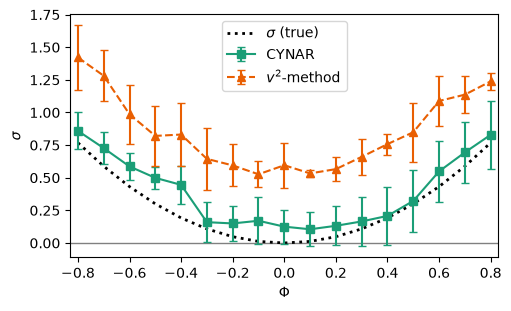

In [7]:
fig, ax = C.plot_equilibrium_bias(
    Phi_list, sigma_cynar_mean, sigma_cynar_std, sigma_v2_mean, sigma_v2_std,
    param_label=r"$\Phi$", sigma_true=sigma_true_list, equilibrium_value=None,
    figsize=(5.,3.),
    save_path=str(C.FIGURES_DIR / "linear_vortex_equilibrium.pdf"),
)
ax.set_xlim(-0.83,0.83)
plt.show()

C.save_result("linear_vortex_equilibrium", dict(
    Phi_list=Phi_list, alph=alph, side_eq=side_eq,
    sigma_true_list=sigma_true_list, Tr_true_list=Tr_true_list,
    sigma_cynar_mean=sigma_cynar_mean, sigma_cynar_std=sigma_cynar_std,
    sigma_v2_mean=sigma_v2_mean, sigma_v2_std=sigma_v2_std,
))